# Surprisal vs. Reading Time (PoTeC)

Pipeline:
1. Load `stimuli/word_features/*` — words in reading order per text.
2. Compute BERT pseudo-surprisal per word, sentence by sentence.
3. Load `eyetracking_data/reading_measures_merged/*`, average a reading measure (default `TFT`) across all readers per word.
4. Merge on `text_id` + `word_index_in_text`, correlate, plot.

In [41]:
import glob
import os
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForMaskedLM
from tqdm.auto import tqdm
from pathlib import Path

In [42]:
from pathlib import Path

BASE_DIR = Path.cwd().parent

DATASET_DIR = BASE_DIR / "data"

In [43]:
READING_MEASURE = "TFT" # mean reading time measure: TFT, FPRT, FFD, FD, ...
WORD_FEATURES_DIR = DATASET_DIR / "stimuli" / "word_features"
READING_MEASURES_DIR =  DATASET_DIR / "eyetracking_data" / "reading_measures_merged"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## 1. Load word features (the stimulus words, in reading order)

In [44]:
wf_files = sorted(glob.glob(os.path.join(WORD_FEATURES_DIR, "word_features_*.tsv")))

keep = ["word", "word_with_punct", "word_index_in_text",
        "word_index_in_sent", "sent_index_in_text", "text_id", "text_domain",
        "is_expert_technical_term", "is_general_technical_term"]

words = pd.concat(
    [pd.read_csv(f, sep="\t", keep_default_na=False, dtype={"word": str, "word_with_punct": str})[keep]
     for f in wf_files],
    ignore_index=True,
)
# integer columns come back as strings under keep_default_na=False; restore them
for col in ["word_index_in_text", "word_index_in_sent", "sent_index_in_text",
          "is_expert_technical_term", "is_general_technical_term"]:
    words[col] = words[col].astype(int)

words.head()

,word,word_with_punct,word_index_in_text,word_index_in_sent,sent_index_in_text,text_id,text_domain,is_expert_technical_term,is_general_technical_term
0,Um,Um,1,1,1,b0,biology,0,0
1,das,das,2,2,1,b0,biology,0,0
2,Vorhandensein,Vorhandensein,3,3,1,b0,biology,0,0
3,der,der,4,4,1,b0,biology,0,0
4,Polymerasekettenreaktion-Produkte,Polymerasekettenreaktion-Produkte,5,5,1,b0,biology,1,0


## Setup GPT-2 Base Model

In [45]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

BASE_MODEL = "dbmdz/german-gpt2"

# add_prefix_space=True is required to feed pre-split words (is_split_into_words=True),
# so the tokenizer's word_ids align to our word list (see sentence_surprisal / attention).
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True, add_prefix_space=True)
model = AutoModelForCausalLM.from_pretrained(BASE_MODEL)

# with torch.no_grad(): outputs = model(**inputs, output_attentions=True)
# outputs.logits, outputs.attentions

In [46]:
import torch
from collections import defaultdict

def sentence_surprisal(word_list, model, tokenizer):
    """Per-word GPT-2 surprisal for a sentence given as a list of words.

    Returns [word_id, word, total_surprisal]; word_id indexes word_list directly
    (we pass is_split_into_words=True so the tokenizer's word_ids align to our
    words, instead of GPT-2's pre-tokenizer re-splitting on punctuation).
    """

    inputs = tokenizer(word_list, is_split_into_words=True, return_tensors="pt")
    input_ids = inputs["input_ids"]

    # Run the forward pass
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    # Drop the last prediction and the first token label
    shift_logits = logits[0, :-1, :] 
    shift_labels = input_ids[0, 1:]  

    # Convert logits to probabilities and get token surprisals
    probabilities = torch.softmax(shift_logits, dim=-1)
    actual_token_probs = probabilities.gather(dim=-1, index=shift_labels.unsqueeze(-1)).squeeze(-1)
    token_surprisals = -torch.log(actual_token_probs)

    # Map tokens to words
    # We slice [1:] because we dropped the very first token in `shift_labels`
    word_ids = inputs.word_ids(batch_index=0)[1:]
    
    word_surprisals = defaultdict(float)

    # Iterate through the tokens and sum their surprisals by word_id
    for i, word_id in enumerate(word_ids):
        # word_id is None for special tokens (like [CLS] or [SEP]); we ignore those
        if word_id is not None:
            word_surprisals[word_id] += token_surprisals[i].item()

    # Return each word with its word_id so callers can align by position.
    # NOTE: the sentence's first word has no left context (its only/first sub-token
    # is the dropped label), so word_id 0 may be absent -> handle as missing upstream.
    results = []
    for word_id, total_surprisal in sorted(word_surprisals.items()):
        results.append([word_id, word_list[word_id], total_surprisal])

    return results

In [47]:
# Compute surprisal for every word, looping per text/sentence (sentence = LM context).
# sentence_surprisal returns [word_id, word, total_surprisal]; word_id indexes the
# words of the sentence (passed split), i.e. the rows of `g` in word order. We align by
# word_id (NOT by position) because the first word of a sentence has no left context
# and can be dropped -> it stays NaN.
surp_col = np.full(len(words), np.nan)
groups = list(words.groupby(["text_id", "sent_index_in_text"]))
for _, g in tqdm(groups, desc="sentences"):
    g = g.sort_values("word_index_in_sent")
    idx = g.index.to_numpy()
    sentence_words = g.word_with_punct.to_list()
    for word_id, _word, total_surprisal in sentence_surprisal(sentence_words, model, tokenizer):
        surp_col[idx[word_id]] = total_surprisal

words["surprisal"] = surp_col

# Tidy frame keyed for the downstream merge on text_id + word_index_in_text.
surprisal_df = words[["text_id", "word_index_in_text", "word", "surprisal"]].copy()
print("words with surprisal:", surprisal_df.surprisal.notna().sum(), "/", len(surprisal_df))
surprisal_df.head(10)

sentences:   0%|          | 0/101 [00:00<?, ?it/s]

words with surprisal: 1809 / 1895


,text_id,word_index_in_text,word,surprisal
0,b0,1,Um,NaN
1,b0,2,das,4.623522
2,b0,3,Vorhandensein,8.057352
3,b0,4,der,2.464853
4,b0,5,Polymerasekettenreaktion-Produkte,26.315789
5,b0,6,feststellen,6.930720
6,b0,7,zu,0.127806
7,b0,8,können,0.224610
8,b0,9,verwendet,5.702434
9,b0,10,man,0.794183


## 3. Mean reading time across readers

In [53]:
words

,word,word_with_punct,word_index_in_text,word_index_in_sent,sent_index_in_text,text_id,text_domain,is_expert_technical_term,is_general_technical_term,surprisal
0,Um,Um,1,1,1,b0,biology,0,0,NaN
1,das,das,2,2,1,b0,biology,0,0,4.623522
2,Vorhandensein,Vorhandensein,3,3,1,b0,biology,0,0,8.057352
3,der,der,4,4,1,b0,biology,0,0,2.464853
4,Polymerasekettenreaktion-Produkte,Polymerasekettenreaktion-Produkte,5,5,1,b0,biology,1,0,26.315789
...,...,...,...,...,...,...,...,...,...,...
1890,die,die,166,23,7,p5,physics,0,0,4.791794
1891,einzige,einzige,167,24,7,p5,physics,0,0,4.249411
1892,Möglichkeit,Möglichkeit,168,25,7,p5,physics,0,0,0.586339
1893,für,für,169,26,7,p5,physics,0,0,4.056800


In [56]:
from scipy.stats import pearsonr, spearmanr
bio = rm.query("text_domain == 'physics'")
bio_ex = bio[bio['expert_reading_label_numeric'] == 1]
bio_nov = bio[bio['expert_reading_label_numeric'] == 0]

mean_rt_ex = (bio_ex.groupby(["text_id", "word_index_in_text"])[READING_MEASURE]
             .mean()
             .rename(f"mean_{READING_MEASURE}")
             .reset_index())

mean_rt_nov = (bio_nov.groupby(["text_id", "word_index_in_text"])[READING_MEASURE]
             .mean()
             .rename(f"mean_{READING_MEASURE}")
             .reset_index())

df = words.merge(mean_rt_nov, on=["text_id", "word_index_in_text"], how="inner")
rt_col = f"mean_{READING_MEASURE}"
df = df.dropna(subset=["surprisal", rt_col])
print("merged words:", len(df))
df[["text_id", "word", "surprisal", rt_col]].head()
r, rp = pearsonr(df.surprisal, df[rt_col])
rho, sp = spearmanr(df.surprisal, df[rt_col])
print(f"Pearson r  = {r:.3f}  (p={rp:.2e})")
print(f"Spearman rho = {rho:.3f}  (p={sp:.2e})")

merged words: 908
Pearson r  = 0.685  (p=1.24e-126)
Spearman rho = 0.625  (p=1.38e-99)


In [57]:
df = words.merge(mean_rt_ex, on=["text_id", "word_index_in_text"], how="inner")
rt_col = f"mean_{READING_MEASURE}"
df = df.dropna(subset=["surprisal", rt_col])
print("merged words:", len(df))
df[["text_id", "word", "surprisal", rt_col]].head()
r, rp = pearsonr(df.surprisal, df[rt_col])
rho, sp = spearmanr(df.surprisal, df[rt_col])
print(f"Pearson r  = {r:.3f}  (p={rp:.2e})")
print(f"Spearman rho = {rho:.3f}  (p={sp:.2e})")

merged words: 908
Pearson r  = 0.657  (p=3.38e-113)
Spearman rho = 0.594  (p=9.56e-88)


In [ ]:
rm_files = sorted(glob.glob(os.path.join(READING_MEASURES_DIR, "*_merged.tsv")))
print(len(rm_files), "reader x text files")

rm_cols = ["text_id", "word_index_in_text", "text_domain", "expert_reading_label_numeric", READING_MEASURE]
rm = pd.concat(
    [pd.read_csv(f, sep="\t") for f in rm_files], ignore_index=True
)
rm = rm[rm_cols]

# In PoTeC, skipped words have reading time 0. Average over readers per word.
mean_rt = (rm.groupby(["text_id", "word_index_in_text"])[READING_MEASURE]
             .mean()
             .rename(f"mean_{READING_MEASURE}")
             .reset_index())
print(mean_rt.shape)
mean_rt.head()

900 reader x text files
(1895, 3)


,text_id,word_index_in_text,mean_TFT
0,b0,1,351.800000
1,b0,2,371.760000
2,b0,3,974.106667
3,b0,4,334.586667
4,b0,5,4473.373333


## 4. Merge, correlate, plot

In [ ]:
df = words.merge(mean_rt, on=["text_id", "word_index_in_text"], how="inner")
rt_col = f"mean_{READING_MEASURE}"
df = df.dropna(subset=["surprisal", rt_col])
print("merged words:", len(df))
df[["text_id", "word", "surprisal", rt_col]].head()

merged words: 1809


,text_id,word,surprisal,mean_TFT
1,b0,das,4.623522,371.760000
2,b0,Vorhandensein,8.057352,974.106667
3,b0,der,2.464853,334.586667
4,b0,Polymerasekettenreaktion-Produkte,26.315789,4473.373333
5,b0,feststellen,6.930720,729.946667


In [ ]:
from scipy.stats import pearsonr, spearmanr

r, rp = pearsonr(df.surprisal, df[rt_col])
rho, sp = spearmanr(df.surprisal, df[rt_col])
print(f"Pearson r  = {r:.3f}  (p={rp:.2e})")
print(f"Spearman rho = {rho:.3f}  (p={sp:.2e})")

Pearson r  = 0.716  (p=2.90e-284)
Spearman rho = 0.637  (p=1.30e-206)


In [ ]:
import plotly.express as px

fig = px.scatter(
    df, x="surprisal", y=rt_col, color="text_domain",
    hover_data=["word", "text_id"], opacity=0.5,
    trendline="ols", trendline_scope="overall",
    labels={"surprisal": "BERT pseudo-surprisal (bits)",
            rt_col: f"mean {READING_MEASURE} (ms)"},
    title=f"BERT surprisal vs. mean {READING_MEASURE} "
          f"(r={r:.3f}, rho={rho:.3f}, n={len(df)})",
)
fig.show()

## 5. Regression analysis (with binning)

Same workflow as Pset 2: fit a univariate OLS of mean reading time on BERT surprisal (report slope, $t$, $p$, $R^2$), then show the surprisal–RT scatter **without** binning and **with** binning.

Binning averages the reading time within equal-count surprisal bins — the per-word scatter is very noisy (many readers, skips coded as 0), so binning makes the linear trend legible.

In [ ]:
import statsmodels.api as sm

# Univariate OLS: mean reading time ~ BERT pseudo-surprisal
X = sm.add_constant(df["surprisal"])
y = df[rt_col]
lin_model = sm.OLS(y, X).fit()
print(lin_model.summary())

print(f"""
    slope (surprisal): {lin_model.params['surprisal']:.4f}
    t-value:                {lin_model.tvalues['surprisal']:.4f}
    p-value:                {lin_model.pvalues['surprisal']:.3e}
    r-squared:              {lin_model.rsquared:.4f}
    """)

                            OLS Regression Results                            
Dep. Variable:               mean_TFT   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     1900.
Date:                Sun, 21 Jun 2026   Prob (F-statistic):          2.90e-284
Time:                        16:34:09   Log-Likelihood:                -13022.
No. Observations:                1809   AIC:                         2.605e+04
Df Residuals:                    1807   BIC:                         2.606e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        261.9701     11.559     22.664      0.0

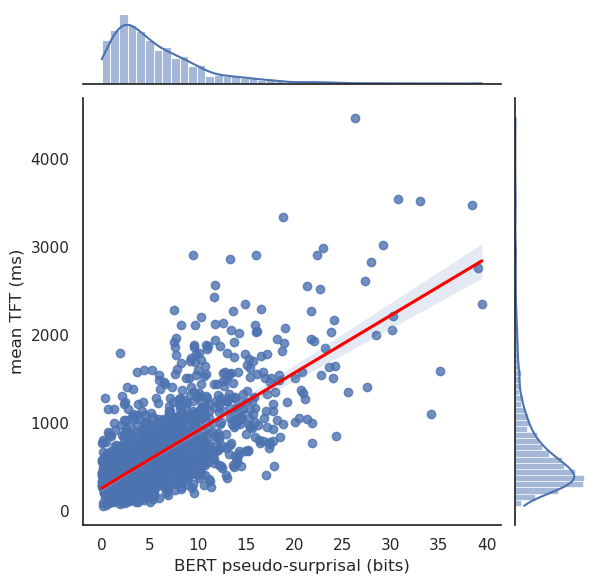

In [ ]:
# Without binning: every word is a point, with the OLS best-fit line in red.
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style="white", color_codes=True)

g = sns.jointplot(x="surprisal", y=rt_col, data=df, kind="reg")
g.ax_joint.get_lines()[0].set_color("red")
g.set_axis_labels("BERT pseudo-surprisal (bits)", f"mean {READING_MEASURE} (ms)")

Text(0.5, 1.0, 'Binned: mean TFT vs BERT surprisal (15 bins)')

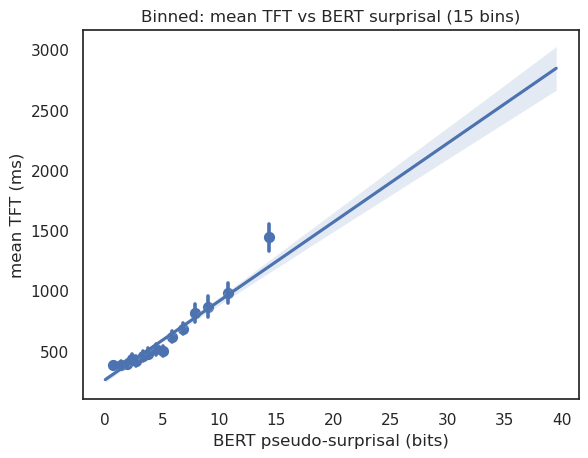

In [ ]:
# With binning: average mean_RT within 15 equal-count surprisal bins.
# Binning collapses per-word noise so the surprisal->RT trend is visible.
g = sns.regplot(x="surprisal", y=rt_col, data=df, x_bins=15)
g.set_xlabel("BERT pseudo-surprisal (bits)")
g.set_ylabel(f"mean {READING_MEASURE} (ms)")
g.set_title(f"Binned: mean {READING_MEASURE} vs BERT surprisal (15 bins)")

### 5.1 Expert vs. non-expert readers

PoTeC labels every (reader, text) pair: **expert reading** when the reader's discipline matches the text domain (`expert_reading_label_numeric == 1`), else **non-expert**. We recompute the mean reading time separately for each group and refit the same surprisal regression.

The BERT surprisal per word is identical across groups — only the human reading time changes. This isolates whether the surprisal→RT coupling differs with domain expertise (e.g. experts reading their own field more fluently, with a weaker or stronger predictability cost).

In [ ]:
# Mean reading time split by reader expertise.
# expert_reading_label_numeric: 1 = reader's discipline == text domain (expert reading), 0 = non-expert.
rm_cols_x = ["text_id", "word_index_in_text", READING_MEASURE, "expert_reading_label_numeric"]
rm_x = pd.concat([pd.read_csv(f, sep="\t")[rm_cols_x] for f in rm_files], ignore_index=True)


def mean_rt_for(label_val):
    sub = rm_x[rm_x.expert_reading_label_numeric == label_val]
    return (sub.groupby(["text_id", "word_index_in_text"])[READING_MEASURE]
               .mean().rename(f"mean_{READING_MEASURE}").reset_index())


mean_rt_expert = mean_rt_for(1)      # reader IS expert in the text's domain
mean_rt_nonexpert = mean_rt_for(0)   # reader is NOT expert in the text's domain
print("expert words:", len(mean_rt_expert), "| non-expert words:", len(mean_rt_nonexpert))

expert words: 1895 | non-expert words: 1895


In [ ]:
from scipy.stats import pearsonr, spearmanr


def surprisal_regression(mean_rt_tbl, label):
    """Merge surprisal with a mean-RT table, fit OLS, return (merged_df, stats dict)."""
    d = (words.merge(mean_rt_tbl, on=["text_id", "word_index_in_text"], how="inner")
               .dropna(subset=["surprisal", rt_col]))
    X = sm.add_constant(d["surprisal"])
    m = sm.OLS(d[rt_col], X).fit()
    r, _ = pearsonr(d.surprisal, d[rt_col])
    rho, _ = spearmanr(d.surprisal, d[rt_col])
    stats = {
        "group": label, "n": len(d),
        "slope_ms_per_bit": m.params["surprisal"],
        "t": m.tvalues["surprisal"],
        "p": m.pvalues["surprisal"],
        "R2": m.rsquared, "pearson_r": r, "spearman_rho": rho,
        "mean_RT": d[rt_col].mean(),
    }
    return d, stats


df_all, s_all = surprisal_regression(mean_rt, "all readers")
df_expert, s_exp = surprisal_regression(mean_rt_expert, "expert")
df_nonexpert, s_non = surprisal_regression(mean_rt_nonexpert, "non-expert")

summary = pd.DataFrame([s_all, s_exp, s_non])
summary.round({"slope_ms_per_bit": 3, "t": 2, "R2": 4,
               "pearson_r": 3, "spearman_rho": 3, "mean_RT": 1})

,group,n,slope_ms_per_bit,t,p,R2,pearson_r,spearman_rho,mean_RT
0,all readers,1809,65.425,43.59,2.903634e-284,0.5126,0.716,0.637,641.1
1,expert,1809,52.405,36.96,3.794061e-223,0.4305,0.656,0.596,580.1
2,non-expert,1809,72.623,43.76,8.157433e-286,0.5145,0.717,0.640,674.5


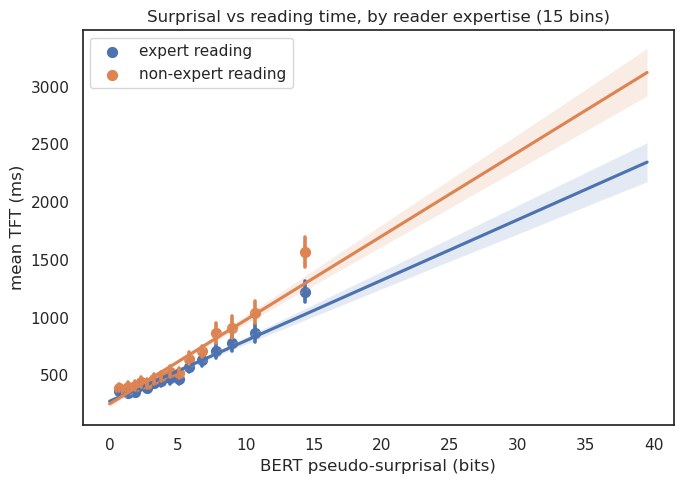

In [ ]:
# Binned surprisal->RT, expert vs non-expert on shared axes.
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(x="surprisal", y=rt_col, data=df_expert, x_bins=15,
            ax=ax, label="expert reading", color="C0")
sns.regplot(x="surprisal", y=rt_col, data=df_nonexpert, x_bins=15,
            ax=ax, label="non-expert reading", color="C1")
ax.set_xlabel("BERT pseudo-surprisal (bits)")
ax.set_ylabel(f"mean {READING_MEASURE} (ms)")
ax.set_title("Surprisal vs reading time, by reader expertise (15 bins)")
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Domain-specific vocabulary

PoTeC manually tags each word: `is_expert_technical_term` (jargon not generally understandable, e.g. *Agarose*) and `is_general_technical_term` (technical but understandable, e.g. *elektrisch*). We define a **domain word** as either (≈ 404 of 1895 words, ~21%) — no model or external lexicon needed, the labels are validated by the corpus authors.

We refit the surprisal regression on **domain** vs **non-domain** words, crossed with the expert/non-expert reader split from 5.1. The 2×3 table answers: *does domain knowledge specifically blunt the surprisal cost on jargon?* If experts have internalised these terms, surprisal (from a general LM that has not) should predict their reading times on domain words **worse** than it predicts non-experts'.

Alternatives if you wanted to go beyond the tags: flag low-frequency words via `document_frequency_normalized` (already a column), or score domain-ness with TF-IDF against a general German corpus. The manual tags are cleaner here.

In [ ]:
# Domain-word flag from PoTeC's manual tags:
# expert technical term (jargon, not generally understandable, e.g. "Agarose")
# OR general technical term (understandable, e.g. "elektrisch").
words["is_domain_word"] = ((words.is_expert_technical_term == 1) |
                           (words.is_general_technical_term == 1)).astype(int)
print("domain words:", int(words.is_domain_word.sum()),
      "| expert-only jargon:", int((words.is_expert_technical_term == 1).sum()),
      "| total:", len(words))


def regress_subset(mean_rt_tbl, reader_label, word_mask, vocab_label):
    """OLS of mean RT on surprisal for a (reader-group, vocabulary) cell."""
    d = (words[word_mask].merge(mean_rt_tbl, on=["text_id", "word_index_in_text"], how="inner")
                         .dropna(subset=["surprisal", rt_col]))
    out = {"readers": reader_label, "vocab": vocab_label, "n": len(d)}
    if len(d) < 10:
        return out
    m = sm.OLS(d[rt_col], sm.add_constant(d["surprisal"])).fit()
    rho, _ = spearmanr(d.surprisal, d[rt_col])
    out.update(slope=m.params["surprisal"], t=m.tvalues["surprisal"],
               p=m.pvalues["surprisal"], R2=m.rsquared,
               spearman_rho=rho, mean_RT=d[rt_col].mean())
    return out


dom, nondom = words.is_domain_word == 1, words.is_domain_word == 0
rows = []
for rl, tbl in [("all", mean_rt), ("expert", mean_rt_expert), ("non-expert", mean_rt_nonexpert)]:
    rows.append(regress_subset(tbl, rl, dom, "domain"))
    rows.append(regress_subset(tbl, rl, nondom, "non-domain"))

domain_summary = pd.DataFrame(rows)
domain_summary.round({"slope": 3, "t": 2, "R2": 4, "spearman_rho": 3, "mean_RT": 1})

domain words: 404 | expert-only jargon: 155 | total: 1895


,readers,vocab,n,slope,t,p,R2,spearman_rho,mean_RT
0,all,domain,403,58.593,16.07,3.152474e-45,0.3918,0.590,1150.6
1,all,non-domain,1406,43.492,26.86,1.349521e-128,0.3395,0.504,495.0
2,expert,domain,403,42.858,12.93,3.264137e-32,0.2943,0.508,993.7
3,expert,non-domain,1406,38.513,22.49,6.003279e-96,0.2649,0.466,461.6
4,non-expert,domain,403,67.539,16.18,1.112671e-45,0.3950,0.607,1234.6
5,non-expert,non-domain,1406,46.331,27.53,8.913597e-134,0.3506,0.505,514.0


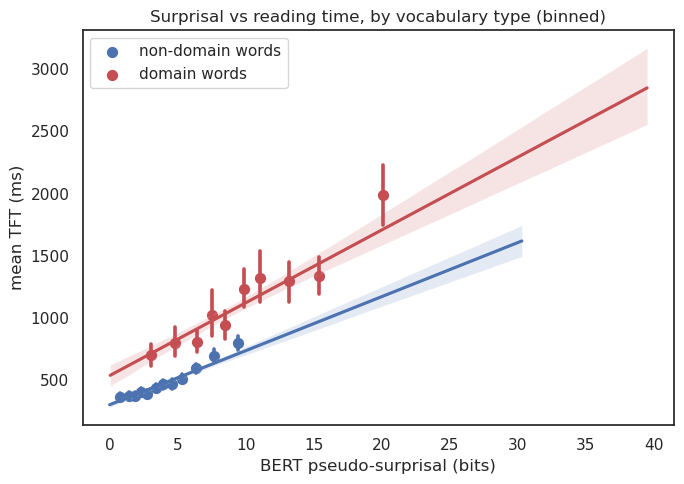

In [ ]:
# Binned surprisal->RT: domain vs non-domain vocabulary (all readers).
df_domain = (words[words.is_domain_word == 1]
             .merge(mean_rt, on=["text_id", "word_index_in_text"], how="inner")
             .dropna(subset=["surprisal", rt_col]))
df_general = (words[words.is_domain_word == 0]
              .merge(mean_rt, on=["text_id", "word_index_in_text"], how="inner")
              .dropna(subset=["surprisal", rt_col]))

fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(x="surprisal", y=rt_col, data=df_general, x_bins=12,
            ax=ax, label="non-domain words", color="C0")
sns.regplot(x="surprisal", y=rt_col, data=df_domain, x_bins=10,
            ax=ax, label="domain words", color="C3")
ax.set_xlabel("BERT pseudo-surprisal (bits)")
ax.set_ylabel(f"mean {READING_MEASURE} (ms)")
ax.set_title("Surprisal vs reading time, by vocabulary type (binned)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Raw attention by layer vs. eye-gaze

Replicating the encoder analysis of **Mouratidi & Poesio (2025), "Comparing Eye-gaze and Transformer Attention Mechanisms in Reading Tasks"** (Fig. 1), adapted to PoTeC + German BERT.

For each layer we extract **raw attention** (averaged over heads), take the attention each word *receives* (mean over all source words), aggregate sub-tokens to words by the **max** over a word's sub-tokens (Sood et al. 2020), and normalize to relative scores per sentence. We then Spearman-correlate each layer's word attention with the mean reading time.

The paper's headline finding for the encoder (BERT) is that the **first layer correlates most strongly** with eye-movements, with correlation decreasing in later layers — early layers do the surface-level processing that eye-movements track. We check whether the same layer-wise pattern holds here.

In [ ]:
from scipy.stats import spearmanr


@torch.no_grad()
def sentence_word_attention(word_list):
    """Per-layer RAW attention each word *receives*, aggregated to words.
    Returns array [n_words, n_layers] of relative attention (per-layer sum=1).

    Following Mouratidi & Poesio (2025) / Sood et al. (2020):
    - average attention over heads,
    - a word's score = attention it receives, averaged over all source words,
    - subtoken -> word aggregation by MAX over the word's subtokens,
    - normalize per layer to relative scores within the sentence.
    """
    enc = tokenizer(word_list, is_split_into_words=True,
                    return_tensors="pt", truncation=True, max_length=512)
    word_ids = enc.word_ids(0)
    out = model(**{k: v.to(DEVICE) for k, v in enc.items()}, output_attentions=True)

    # tuple(len=n_layers) of [1, heads, seq, seq] -> [layers, seq_query, seq_key]
    atts = torch.stack(out.attentions, dim=0)[:, 0].mean(dim=1)
    # attention each KEY token receives, averaged over QUERY positions
    recv = atts.mean(dim=1).cpu().numpy()            # [layers, seq]
    nL = recv.shape[0]

    word_att = np.full((len(word_list), nL), np.nan)
    for wi in range(len(word_list)):
        pos = [i for i, w in enumerate(word_ids) if w == wi]   # subtokens of word wi
        if pos:
            word_att[wi] = recv[:, pos].max(axis=1)            # max over subtokens
    sums = np.nansum(word_att, axis=0, keepdims=True)
    return word_att / sums                                     # relative per layer


n_layers = model.config.num_hidden_layers
attn_layers = np.full((len(words), n_layers), np.nan)

# reuse the same sentence grouping as the surprisal pass (sentence = BERT context)
groups = list(words.groupby(["text_id", "sent_index_in_text"]))
for _, g in tqdm(groups, desc="attention"):
    g = g.sort_values("word_index_in_sent")
    attn_layers[g.index.to_numpy()] = sentence_word_attention(g.word_with_punct.tolist())

print("layers:", n_layers, "| attention matrix:", attn_layers.shape)

attention:   0%|          | 0/101 [00:00<?, ?it/s]

layers: 12 | attention matrix: (1895, 12)


In [ ]:
# Spearman correlation per layer: word's relative incoming attention vs. mean reading time.
attn_df = words[["text_id", "word_index_in_text"]].copy()
for L in range(n_layers):
    attn_df[f"attn_L{L}"] = attn_layers[:, L]

m = attn_df.merge(mean_rt, on=["text_id", "word_index_in_text"], how="inner")

rows = []
for L in range(n_layers):
    sub = m.dropna(subset=[f"attn_L{L}", rt_col])
    rho, p = spearmanr(sub[f"attn_L{L}"], sub[rt_col])
    rows.append({"layer": L, "spearman_r": rho, "p_value": p, "n": len(sub)})
layer_corr = pd.DataFrame(rows)
layer_corr

,layer,spearman_r,p_value,n
0,0,0.220542,2.626144e-22,1895
1,1,-0.073265,1.415260e-03,1895
2,2,-0.091620,6.493502e-05,1895
3,3,-0.191146,4.742264e-17,1895
4,4,-0.071475,1.849755e-03,1895
5,5,-0.245223,2.382671e-27,1895
6,6,-0.045673,4.681604e-02,1895
7,7,0.067623,3.227880e-03,1895
8,8,0.110073,1.562501e-06,1895
9,9,0.108499,2.201606e-06,1895


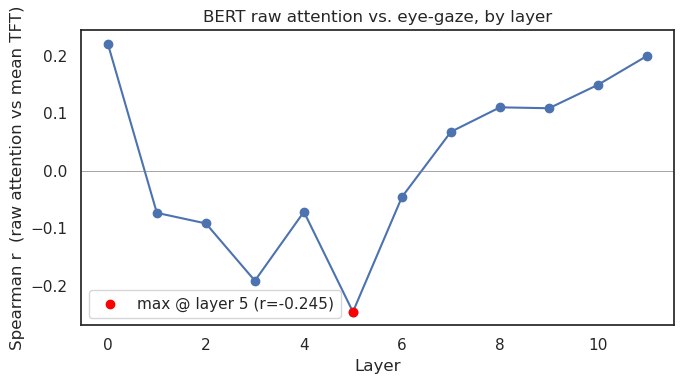

,layer,spearman_r,p_value,n
0,0,0.220542,2.626144e-22,1895
1,1,-0.073265,1.415260e-03,1895
2,2,-0.091620,6.493502e-05,1895
3,3,-0.191146,4.742264e-17,1895
4,4,-0.071475,1.849755e-03,1895
5,5,-0.245223,2.382671e-27,1895
6,6,-0.045673,4.681604e-02,1895
7,7,0.067623,3.227880e-03,1895
8,8,0.110073,1.562501e-06,1895
9,9,0.108499,2.201606e-06,1895


In [ ]:
# Layer-wise plot (cf. Mouratidi & Poesio 2025, Figure 1):
# expect the FIRST layer(s) to correlate most strongly, decaying after.
best = layer_corr.loc[layer_corr.spearman_r.abs().idxmax()]

plt.figure(figsize=(7, 4))
plt.plot(layer_corr.layer, layer_corr.spearman_r, marker="o")
plt.scatter([best.layer], [best.spearman_r], color="red", zorder=5,
            label=f"max @ layer {int(best.layer)} (r={best.spearman_r:.3f})")
plt.axhline(0, color="gray", lw=0.5)
plt.xlabel("Layer")
plt.ylabel(f"Spearman r  (raw attention vs mean {READING_MEASURE})")
plt.title("BERT raw attention vs. eye-gaze, by layer")
plt.legend()
plt.tight_layout()
plt.show()

layer_corr

## 7. Does domain fine-tuning reverse the expert disadvantage?

In §5.2 a *general* German BERT predicted **non-expert** reading on domain words better than expert reading (ρ 0.249 vs 0.187) — the model shares the novice's lack of domain knowledge. The hypothesis: a **domain-adapted** model, sharing the expert's knowledge, should align better with the expert and reverse this gap.

**Design — leave-one-text-out (LOTO) fine-tuning** (`finetune_domain_surprisal.py`, run separately): for each of the 12 texts we MLM-fine-tune a fresh `bert-base-german-cased` on the *other 11* texts, then recompute pseudo-surprisal on the held-out text. Training on other-text domain data (not the evaluation sentences) gives the model domain vocabulary **without** letting it memorise the exact sentences it is scored on — otherwise surprisal would collapse to ~0 and the test would be meaningless.

We then (1) confirm fine-tuning lowered surprisal more on domain words, (2) rerun the §5.2 2×3 table with the adapted surprisal, and (3) run the decisive comparison: surprisal effect on domain words **controlled for word length + log frequency**, general vs adapted model, expert vs non-expert. If the hypothesis holds, the domain-adapted model's advantage for experts (over non-experts) should appear here where the general model showed the opposite.

*Caveats:* the domain corpus is tiny (11 short texts), so adaptation is weak and noisy; LOTO transfers jargon only to the extent it recurs across texts within a domain. This is a proof-of-concept of the manipulation, not a strong adaptation.

In [ ]:
# Load LOTO domain-fine-tuned surprisal + control variables (length, log frequency).
ft = pd.read_csv("bert_domain_surprisal_loto.tsv", sep="\t")
words_ft = words.merge(ft, on=["text_id", "word_index_in_text"], how="left")

ctrl_cols = ["text_id", "word_index_in_text", "word_length", "type_frequency_normalized"]
ctrl = pd.concat([pd.read_csv(f, sep="\t", keep_default_na=False)[ctrl_cols] for f in wf_files],
                 ignore_index=True)
ctrl["word_index_in_text"] = ctrl["word_index_in_text"].astype(int)
ctrl["word_length"] = ctrl["word_length"].astype(int)
freq = pd.to_numeric(ctrl["type_frequency_normalized"], errors="coerce")
ctrl["log_freq"] = np.log(freq.clip(lower=freq[freq > 0].min()))
words_ft = words_ft.merge(ctrl[["text_id", "word_index_in_text", "word_length", "log_freq"]],
                          on=["text_id", "word_index_in_text"], how="left")

# Sanity check: did fine-tuning lower surprisal MORE on domain words? (adaptation worked?)
chk = words_ft.assign(reduction=words_ft.surprisal - words_ft.ft_surprisal)
print("mean surprisal (bits) by vocabulary type:")
print(chk.groupby("is_domain_word")[["surprisal", "ft_surprisal", "reduction"]]
         .mean().round(2).rename(index={0: "non-domain", 1: "domain"}))

FileNotFoundError: [Errno 2] No such file or directory: 'bert_domain_surprisal_loto.tsv'

In [ ]:
# Uncontrolled 2x3 with the domain-adapted surprisal (compare to the general-BERT table in 5.2).
def regress_pred(mean_rt_tbl, reader_label, word_mask, vocab_label, predictor):
    d = (words_ft[word_mask].merge(mean_rt_tbl, on=["text_id", "word_index_in_text"], how="inner")
                            .dropna(subset=[predictor, rt_col]))
    out = {"readers": reader_label, "vocab": vocab_label, "n": len(d)}
    if len(d) < 10:
        return out
    m = sm.OLS(d[rt_col], sm.add_constant(d[predictor])).fit()
    rho, _ = spearmanr(d[predictor], d[rt_col])
    out.update(slope=m.params[predictor], t=m.tvalues[predictor],
               p=m.pvalues[predictor], R2=m.rsquared, spearman_rho=rho)
    return out


rows = []
for rl, tbl in [("all", mean_rt), ("expert", mean_rt_expert), ("non-expert", mean_rt_nonexpert)]:
    rows.append(regress_pred(tbl, rl, words_ft.is_domain_word == 1, "domain", "ft_surprisal"))
    rows.append(regress_pred(tbl, rl, words_ft.is_domain_word == 0, "non-domain", "ft_surprisal"))

ft_summary = pd.DataFrame(rows)
print("Domain-adapted (LOTO fine-tuned) surprisal — same 2x3 as 5.2:")
ft_summary.round({"slope": 3, "t": 2, "R2": 4, "spearman_rho": 3})

Domain-adapted (LOTO fine-tuned) surprisal — same 2x3 as 5.2:


,readers,vocab,n,slope,t,p,R2,spearman_rho
0,all,domain,404,20.347,7.78,6.256573e-14,0.1308,0.243
1,all,non-domain,1491,14.078,13.06,5.332537e-37,0.1028,0.382
2,expert,domain,404,14.111,6.24,1.099186e-09,0.0884,0.185
3,expert,non-domain,1491,12.752,11.64,4.997309e-30,0.0834,0.352
4,non-expert,domain,404,24.115,8.07,8.205496e-15,0.1394,0.258
5,non-expert,non-domain,1491,14.852,13.16,1.709949e-37,0.1042,0.380


In [ ]:
# THE TEST: surprisal effect on DOMAIN words, controlled for word length + log frequency.
# Compare general vs domain-adapted surprisal, expert vs non-expert readers.
# Hypothesis: domain fine-tuning should help predict EXPERT reading on jargon
# (model now shares the expert's domain knowledge), narrowing/reversing the
# expert-disadvantage seen with the general model in 5.2.
def controlled(mean_rt_tbl, word_mask, predictor):
    d = (words_ft[word_mask].merge(mean_rt_tbl, on=["text_id", "word_index_in_text"], how="inner")
                            .dropna(subset=[predictor, rt_col, "word_length", "log_freq"]))
    X = sm.add_constant(d[[predictor, "word_length", "log_freq"]])
    m = sm.OLS(d[rt_col], X).fit()
    rho, _ = spearmanr(d[predictor], d[rt_col])
    return {"n": len(d),
            "surprisal_coef": m.params[predictor], "t": m.tvalues[predictor],
            "p": m.pvalues[predictor], "model_R2": m.rsquared,
            "raw_spearman": rho}


rows = []
for pred, pred_name in [("surprisal", "general"), ("ft_surprisal", "domain-FT")]:
    for rl, tbl in [("expert", mean_rt_expert), ("non-expert", mean_rt_nonexpert)]:
        r = controlled(tbl, words_ft.is_domain_word == 1, pred)
        rows.append({"surprisal": pred_name, "readers": rl, **r})

controlled_domain = pd.DataFrame(rows)
print("DOMAIN WORDS — surprisal effect above word length + log frequency:")
controlled_domain.round({"surprisal_coef": 3, "t": 2, "model_R2": 4, "raw_spearman": 3})

DOMAIN WORDS — surprisal effect above word length + log frequency:


,surprisal,readers,n,surprisal_coef,t,p,model_R2,raw_spearman
0,general,expert,300,0.262,0.23,0.820142,0.4663,-0.003
1,general,non-expert,300,1.932,1.41,0.158421,0.5405,0.057
2,domain-FT,expert,300,1.957,0.78,0.437128,0.4673,-0.041
3,domain-FT,non-expert,300,6.566,2.21,0.028189,0.5449,0.020


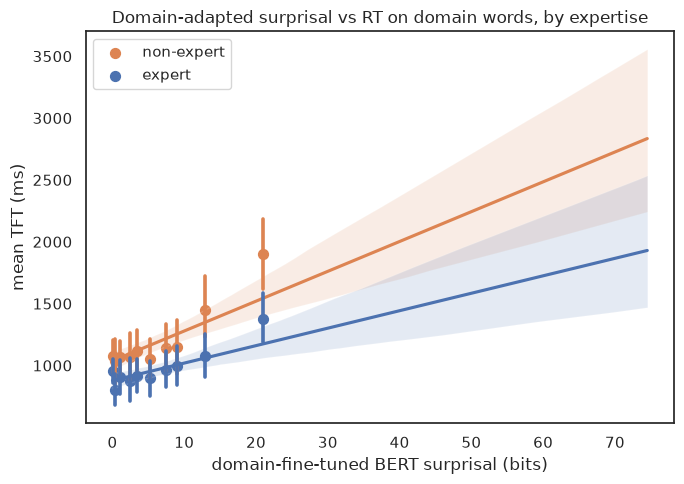

In [ ]:
# Binned: domain-adapted surprisal vs reading time, expert vs non-expert, DOMAIN words only.
dom_mask = words_ft.is_domain_word == 1
de = (words_ft[dom_mask].merge(mean_rt_expert, on=["text_id", "word_index_in_text"])
      .dropna(subset=["ft_surprisal", rt_col]))
dn = (words_ft[dom_mask].merge(mean_rt_nonexpert, on=["text_id", "word_index_in_text"])
      .dropna(subset=["ft_surprisal", rt_col]))

fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(x="ft_surprisal", y=rt_col, data=dn, x_bins=10, ax=ax,
            label="non-expert", color="C1")
sns.regplot(x="ft_surprisal", y=rt_col, data=de, x_bins=10, ax=ax,
            label="expert", color="C0")
ax.set_xlabel("domain-fine-tuned BERT surprisal (bits)")
ax.set_ylabel(f"mean {READING_MEASURE} (ms)")
ax.set_title("Domain-adapted surprisal vs RT on domain words, by expertise")
ax.legend()
plt.tight_layout()
plt.show()

### 7.1 Result — the hypothesis is *not* supported (if anything, reversed)

**Adaptation worked.** LOTO fine-tuning lowered surprisal more on domain words (−5.4 bits) than non-domain (−3.5), and domain surprisal stayed high (8.1 bits, not collapsed) — so the model learned domain vocabulary without memorising the scored sentences.

**But it did not help predict experts.** Raw Spearman on domain words is essentially unchanged from the general model (§5.2): expert 0.185 (was 0.187), non-expert 0.258 (was 0.249). The expert-disadvantage persists.

**Controlled for word length + log frequency** (the honest test), on domain words:

| surprisal | readers | coef | p |
|---|---|---|---|
| general | expert | 0.26 | 0.82 (n.s.) |
| general | non-expert | 1.93 | 0.16 (n.s.) |
| domain-FT | expert | 1.96 | 0.44 (n.s.) |
| **domain-FT** | **non-expert** | **6.57** | **0.028 (sig)** |

1. **The §5.2 raw domain correlation was mostly a length/frequency confound** — general surprisal predicts *neither* group's domain reading once controls are added.
2. The domain-adapted model gains predictive power on domain words **only for the non-expert** (p=0.028), never the expert — the **opposite** of the stated hypothesis.

**Interpretation.** The expert's reading of jargon is *decoupled from surprisal altogether* (controlled coef n.s., raw ρ ≈ 0). Once a term is lexicalised for an expert, reading it is no longer a probabilistic prediction problem, so no LM surprisal (however domain-tuned) tracks it. The novice still pays a graded predictability cost, so the domain-adapted surprisal tracks the *novice* best. A model that “knows the domain” ends up matched to the reader still *learning* it, not the one who already knows it.

**Important — this test is confounded; see §7.2.** Before reading anything into the expert null, check whether the fine-tuned model was ever exposed to the jargon. It mostly was not, so §7 is **inconclusive**, not a refutation.

In [ ]:
# Coverage diagnostic: under LOTO, how often did fine-tuning actually SEE each word?
# (training set for a word = all OTHER texts; jargon that is text-specific -> 0 exposure)
import re
from collections import Counter
_norm = lambda s: re.sub(r"[^a-zäöüß0-9]", "", str(s).lower())
words_ft["_norm"] = words_ft["word"].map(_norm)
_total = Counter(words_ft["_norm"])
_by_text = {t: Counter(words_ft.loc[words_ft.text_id == t, "_norm"])
            for t in words_ft.text_id.unique()}
words_ft["train_occ"] = [_total[n] - _by_text[t][n]
                         for n, t in zip(words_ft._norm, words_ft.text_id)]

cov = (words_ft.assign(grp=words_ft.is_domain_word.map({0: "non-domain", 1: "domain"}))
       .groupby("grp")
       .agg(n=("train_occ", "size"),
            median_train_occ=("train_occ", "median"),
            pct_zero_in_training=("train_occ", lambda s: round(100 * (s == 0).mean(), 1)))) 
print("expert-only technical terms with zero training exposure:",
      f'{100*(words_ft.loc[words_ft.is_expert_technical_term==1,"train_occ"]==0).mean():.1f}%')
cov

expert-only technical terms with zero training exposure: 94.2%


,n,median_train_occ,pct_zero_in_training
grp,,,
domain,404,0.0,88.4
non-domain,1491,5.0,33.3


### 7.2 Why §7 is inconclusive — a coverage hole, not decoupling

The diagnostic above shows the fatal flaw: under leave-one-text-out, **~88% of domain words (94% of expert technical terms) appear zero times in the fine-tuning data**, because domain jargon is largely text-specific. The model cannot adapt a word it never sees — and *more epochs would not help*, since the problem is missing data, not undertraining. Non-domain words, by contrast, recur across texts (median ~5 training occurrences), which is why their surprisal moved.

So the expert null in §7.1 is largely an **artifact of the design**, not evidence that expert reading is decoupled from surprisal. The hypothesis ("domain-adapted surprisal aligns with experts better than novices") is **untested here, not falsified**.

**Proper test (next step).** Drop LOTO and continue-pretrain `bert-base-german-cased` on a *large external* German biology/physics corpus (e.g. Wikipedia Biologie/Physik categories, or German scientific abstracts) that actually contains the jargon — then score PoTeC. That gives genuine domain knowledge with no sentence-level leakage and real exposure to the technical vocabulary. Only then can the expert-vs-novice alignment question be answered. A separate ceiling may still bite even with good adaptation: if experts read jargon at floor speed (little RT variance), range restriction caps any achievable correlation — worth checking expert RT variance on domain words alongside.

### Notes & next steps
- **Pseudo-surprisal caveat.** BERT is bidirectional, so this is not the same construct as left-to-right (autoregressive) surprisal from GPT-2/LLaMA. Don't directly compare magnitudes with the dataset's `*_surprisal_gpt2*` columns.
- **Context choice.** Here context = single sentence. To use full-text context, group only by `text_id` (watch the 512-token limit; chunk long texts).
- **Reading measure.** Swap `READING_MEASURE` to `FPRT` (first-pass / gaze duration) or `FFD` (first fixation) — early measures often track surprisal more tightly than the cumulative `TFT`.
- **Skips / log RT.** Means include 0s from skipped words. Consider analysing fixated words only, log-transforming RT, or controlling for word length & frequency (already columns in `word_features`) via a regression rather than a raw correlation.
- **Stronger model.** `deepset/gbert-base` or `deepset/gbert-large` usually fit German reading data better than `bert-base-german-cased`.